# Testing Hypervolume

In [25]:
# This code creates a reference set from the different seeds

# NOTE: For MMBorg archives, run the script to convert it to the format recognized by older code with ema-workbench.
# Example 
# python justice/util/borg_archive_processor.py     --archive /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/mm_intermediate.zip     --base-name MOMA_200000_ref2_11     --step 10000

from solvers.convergence.hypervolume import get_global_reference_set, calculate_hypervolume_from_archives
import multiprocessing
# Suppress warnings
import warnings

from justice.util.enumerations import WelfareFunction, SSP
from justice.util.visualizer import plot_hypervolume

warnings.filterwarnings("ignore")

base_path = "data/temporary/MOMA_DATA/200k" # Change this to your path

swf = WelfareFunction.UTILITARIAN
nfe = 200_000
ssp = SSP.SSP2
ssp_ref = 2
seed = 11
path = f"{base_path}/"
welfare_epsilon = 20


print(f"Loading data from {path}...")

list_of_objectives = [
    "macro_welfare_R5ASIA",
    "macro_welfare_R5LAM",
    "macro_welfare_R5MAF",
    "macro_welfare_R5OECD",
    "macro_welfare_R5REF",
    "fraction_above_threshold",
]
data_path = path 

direction_of_optimization = ["max", "max", "max", "max", "max", "min"] #, "max", "max"

get_global_reference_set(
    list_of_objectives=list_of_objectives,
    data_path=data_path,
    #file_name=None,
    swf="MOMA",
    nfe=str(nfe), # Ran for 50k number of function evaluations

    # Setting the same epsilon values as optimization process  (see analysis/analyzer.py)
    epsilons=[welfare_epsilon, welfare_epsilon, welfare_epsilon, welfare_epsilon, welfare_epsilon, 0.01],


    direction_of_optimization=direction_of_optimization,
    output_data_path=path,
    saving=True,
)




Loading data from data/temporary/MOMA_DATA/200k/...
Loading list of files
Loading archives for:  MOMA
Filename:  MOMA_200000_ref2_11_3.tar.gz
Matching file: MOMA_200000_ref2_11_3.tar.gz
Loading archives from: MOMA_200000_ref2_11_3.tar.gz
Max key: 200000
Number of rows in archive: 219
Archives loaded for: MOMA_200000_ref2_11_3.tar.gz
Filename:  .DS_Store
Filename:  MOMA_200000_ref2_11_1.tar.gz
Matching file: MOMA_200000_ref2_11_1.tar.gz
Loading archives from: MOMA_200000_ref2_11_1.tar.gz
Max key: 200000
Number of rows in archive: 187
Archives loaded for: MOMA_200000_ref2_11_1.tar.gz
Filename:  mm_intermediate.zip
Filename:  MOMA_reference_set.csv
Filename:  200000.csv
Filename:  MOMA_200000_ref2_11_2.tar.gz
Matching file: MOMA_200000_ref2_11_2.tar.gz
Loading archives from: MOMA_200000_ref2_11_2.tar.gz
Max key: 200000
Number of rows in archive: 205
Archives loaded for: MOMA_200000_ref2_11_2.tar.gz
Filename:  hypervolumes
Filename:  MOMA_200000_ref2_11_0.tar.gz
Matching file: MOMA_200000_

{'MOMA':      center 0 0  center 0 1  center 0 2  center 0 3  center 0 4  center 0 5  \
 59    -0.619993    0.323968    0.435647   -0.938114    0.589213   -0.059662   
 69    -0.511022    0.109210    0.293913    0.482633    0.778335    0.317642   
 70     0.014435   -0.439555   -0.388713   -0.901318    0.879460   -0.080367   
 83    -0.131153   -0.462470   -0.130272    0.087914   -0.087903    0.384283   
 101   -0.289679   -0.122535    0.432308    0.049255    0.533646   -0.164673   
 ..          ...         ...         ...         ...         ...         ...   
 796   -0.160072    0.024929   -0.968083    0.853577   -0.971522    0.206843   
 802    0.136427    0.705032    0.074885   -0.040359   -0.948383    0.883205   
 803   -0.596837   -0.309918   -0.897571    0.991443   -0.591336    0.312082   
 815    0.427069   -0.971060   -0.976195    0.487515   -0.321011    0.222040   
 821   -0.160072    0.024929   -0.968083    0.853577   -0.971522    0.206843   
 
      center 0 6  center 0 7  

In [1]:
# Read the reference set csv
import pandas as pd

path = "data/temporary/MOMA_DATA/200k" # Change this to your path

reference_set = pd.read_csv(f"{path}/MOMA_reference_set.csv")
# reference_set = pd.read_csv("100000.csv")

# Print reading from path and filename
# print(f"Reading reference set from {path}/MOMA_reference_set.csv")
# Print number of rows
print(f"Reference set size: {reference_set.shape[0]}")



df = reference_set

# Keep the last 6 columns
df_last6 = df.iloc[:, -6:]

# Print min and max of each of the last 6 columns
for column in df_last6.columns:
    print(f"{column}: min = {df_last6[column].min()}, max = {df_last6[column].max()}")
    # print difference between max and min
    print(f"{column}: range = {df_last6[column].max() - df_last6[column].min()}")


# Normalize the last 6 columns between 0 and 1
df_normalized = df_last6.copy()
for column in df_normalized.columns:
    min_val = df_normalized[column].min()
    max_val = df_normalized[column].max()
    df_normalized[column] = (df_normalized[column] - min_val) / (max_val - min_val)

# Use plotly to create a parallel axes plot
import plotly.express as px
fig = px.parallel_coordinates(
    df_normalized,
    dimensions=df_normalized.columns,
    title="Parallel Coordinates Plot of Normalized Objectives",
)
fig.show()


Reference set size: 71
macro_welfare_R5ASIA: min = 2051.7692606588444, max = 2123.3216154668426
macro_welfare_R5ASIA: range = 71.5523548079982
macro_welfare_R5LAM: min = 2765.56469044951, max = 2922.426506207547
macro_welfare_R5LAM: range = 156.86181575803676
macro_welfare_R5MAF: min = 2597.8107373268103, max = 2680.8116518452025
macro_welfare_R5MAF: range = 83.00091451839216
macro_welfare_R5OECD: min = 3319.1318965466426, max = 3441.191004115174
macro_welfare_R5OECD: range = 122.05910756853154
macro_welfare_R5REF: min = 2072.516402851923, max = 2186.335620898738
macro_welfare_R5REF: range = 113.81921804681497
fraction_above_threshold: min = 0.56, max = 0.88
fraction_above_threshold: range = 0.31999999999999995


In [ ]:
import pandas as pd
import numpy as np

# Define which objectives belong to which agent
agent_objectives = {
    "agent_1": ["macro_welfare_R5ASIA", "fraction_above_threshold"],
    "agent_2": ["macro_welfare_R5LAM", "fraction_above_threshold"],
    "agent_3": ["macro_welfare_R5MAF", "fraction_above_threshold"],
    "agent_4": ["macro_welfare_R5OECD", "fraction_above_threshold"],
    "agent_5": ["macro_welfare_R5REF", "fraction_above_threshold"],
}


num_agents = 5
num_solutions = len(df)


def is_pareto_dominated(solution_idx, agent_name, df, agent_objectives, 
                         minimize_objectives=["fraction_above_threshold"]):
    """
    Check if solution_idx is Pareto-dominated by any other solution
    for the given agent's objectives.
    
    minimize_objectives: list of objectives to MINIMIZE (rest are maximized)
    
    Returns: True if dominated, False if non-dominated
    """
    objectives = agent_objectives[agent_name]
    
    # Get this solution's outcome for this agent
    solution_outcome = df.loc[solution_idx, objectives].values
    
    # Compare against all other solutions
    for other_idx in range(len(df)):
        if other_idx == solution_idx:
            continue
        
        other_outcome = df.loc[other_idx, objectives].values
        
        # Check Pareto dominance considering min/max per objective
        at_least_as_good = True
        strictly_better = False
        
        for i, obj in enumerate(objectives):
            if obj in minimize_objectives:
                # For minimization: lower is better
                if other_outcome[i] > solution_outcome[i]:
                    # other is worse (higher) on this minimization objective
                    at_least_as_good = False
                    break
                elif other_outcome[i] < solution_outcome[i]:
                    # other is better (lower) on this minimization objective
                    strictly_better = True
            else:
                # For maximization: higher is better
                if other_outcome[i] < solution_outcome[i]:
                    # other is worse (lower) on this maximization objective
                    at_least_as_good = False
                    break
                elif other_outcome[i] > solution_outcome[i]:
                    # other is better (higher) on this maximization objective
                    strictly_better = True
        
        if at_least_as_good and strictly_better:
            # other_outcome dominates solution_outcome
            return True
    
    return False

# ============================================================
# STAGE 2: Check Pareto-Nash for each solution and each agent
# ============================================================

pareto_nash_set = []

for solution_idx in range(num_solutions):
    is_pareto_nash = True
    
    # Check all agents
    for agent_name in agent_objectives.keys():
        
        # Check if this solution is Pareto-dominated for this agent
        if is_pareto_dominated(solution_idx, agent_name, df, agent_objectives,
                               minimize_objectives=["fraction_above_threshold"]):

            is_pareto_nash = False
            break
    
    if is_pareto_nash:
        pareto_nash_set.append(solution_idx)
        print(f"Solution {solution_idx} is PARETO-NASH ✓")

print(f"\nPareto-Nash set: {pareto_nash_set}")
print(f"Pareto-Nash front:\n{df.loc[pareto_nash_set]}")


Solution 23 is PARETO-NASH ✓

Pareto-Nash set: [23]
Pareto-Nash front:
    center 0 0  center 0 1  center 0 2  center 0 3  center 0 4  center 0 5  \
23    0.140522   -0.483795    0.294952   -0.930616     0.64594   -0.809481   

    center 0 6  center 0 7  center 0 8  center 0 9  ...  weights 4 1  \
23   -0.923755   -0.435169   -0.345298   -0.034383  ...     0.000012   

    weights 4 2  weights 4 3  weights 4 4  macro_welfare_R5ASIA  \
23     0.027069     0.021072     0.742452           2097.463416   

    macro_welfare_R5LAM  macro_welfare_R5MAF  macro_welfare_R5OECD  \
23          2852.168874          2680.811652           3351.997653   

    macro_welfare_R5REF  fraction_above_threshold  
23           2102.11335                      0.56  

[1 rows x 181 columns]


In [9]:
import pandas as pd
import numpy as np


# Define which objectives belong to which agent
agent_objectives = {
    "agent_1": ["macro_welfare_R5ASIA", "fraction_above_threshold"],
    "agent_2": ["macro_welfare_R5LAM", "fraction_above_threshold"],
    "agent_3": ["macro_welfare_R5MAF", "fraction_above_threshold"],
    "agent_4": ["macro_welfare_R5OECD", "fraction_above_threshold"],
    "agent_5": ["macro_welfare_R5REF", "fraction_above_threshold"],
}

num_agents = 5
num_solutions = len(df)

def is_pareto_dominated(solution_idx, agent_name, df, agent_objectives, 
                         minimize_objectives=["fraction_above_threshold"],
                         verbose=False):
    """
    Check if solution_idx is Pareto-dominated by any other solution
    for the given agent's objectives.
    
    minimize_objectives: list of objectives to MINIMIZE (rest are maximized)
    verbose: if True, print detailed comparison
    
    Returns: True if dominated, False if non-dominated
    """
    objectives = agent_objectives[agent_name]
    
    # Get this solution's outcome for this agent
    solution_outcome = df.loc[solution_idx, objectives].values
    
    if verbose:
        print(f"\n  Checking {agent_name}")
        print(f"    Original solution {solution_idx}: {solution_outcome}")
        print(f"    Objectives: {objectives}")
    
    # Compare against all other solutions
    for other_idx in range(len(df)):
        if other_idx == solution_idx:
            continue
        
        other_outcome = df.loc[other_idx, objectives].values
        
        # Check Pareto dominance considering min/max per objective
        at_least_as_good = True
        strictly_better = False
        comparison_details = []
        
        for i, obj in enumerate(objectives):
            if obj in minimize_objectives:
                # For minimization: lower is better
                if other_outcome[i] > solution_outcome[i]:
                    # other is worse (higher) on this minimization objective
                    at_least_as_good = False
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} > {solution_outcome[i]:.4f} (other WORSE)")
                    break
                elif other_outcome[i] < solution_outcome[i]:
                    # other is better (lower) on this minimization objective
                    strictly_better = True
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} < {solution_outcome[i]:.4f} (other BETTER)")
                else:
                    # Equal
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} = {solution_outcome[i]:.4f} (EQUAL)")
            else:
                # For maximization: higher is better
                if other_outcome[i] < solution_outcome[i]:
                    # other is worse (lower) on this maximization objective
                    at_least_as_good = False
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} < {solution_outcome[i]:.4f} (other WORSE)")
                    break
                elif other_outcome[i] > solution_outcome[i]:
                    # other is better (higher) on this maximization objective
                    strictly_better = True
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} > {solution_outcome[i]:.4f} (other BETTER)")
                else:
                    # Equal
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} = {solution_outcome[i]:.4f} (EQUAL)")
        
        if verbose:
            print(f"      vs Solution {other_idx}: {other_outcome}")
            for detail in comparison_details:
                print(f"        {detail}")
        
        if at_least_as_good and strictly_better:
            # other_outcome dominates solution_outcome
            if verbose:
                print(f"      ✗ DOMINATES! Solution {other_idx} Pareto-dominates solution {solution_idx}")
            return True
        elif verbose and not at_least_as_good:
            print(f"      ✓ Does NOT dominate (other is worse on some objective)")
    
    return False


# ============================================================
# STAGE 2: Check Pareto-Nash for each solution and each agent
# ============================================================

pareto_nash_set = []

for solution_idx in range(num_solutions):
    is_pareto_nash = True
    
    print(f"\n{'='*80}")
    print(f"TESTING SOLUTION {solution_idx}")
    print(f"{'='*80}")
    
    # Check all agents
    for agent_name in agent_objectives.keys():
        
        # Check if this solution is Pareto-dominated for this agent
        if is_pareto_dominated(solution_idx, agent_name, df, agent_objectives,
                               minimize_objectives=["fraction_above_threshold"],
                               verbose=True):
            
            print(f"\n  ✗ Solution {solution_idx} is NOT Pareto-Nash for {agent_name}")
            print(f"     (Agent {agent_name} found a unilateral improvement)")
            is_pareto_nash = False
            break
        else:
            print(f"\n  ✓ Solution {solution_idx} is NON-DOMINATED for {agent_name}")
            print(f"     (Agent {agent_name} cannot improve unilaterally)")
    
    if is_pareto_nash:
        pareto_nash_set.append(solution_idx)
        print(f"\n{'='*80}")
        print(f"✓✓✓ Solution {solution_idx} is PARETO-NASH ✓✓✓")
        print(f"{'='*80}")


print(f"\n\n{'='*80}")
print(f"FINAL RESULT")
print(f"{'='*80}")
print(f"Pareto-Nash set: {pareto_nash_set}")
print(f"\nPareto-Nash front:\n{df.loc[pareto_nash_set]}")



TESTING SOLUTION 0

  Checking agent_1
    Original solution 0: [2.12332162e+03 6.80000000e-01]
    Objectives: ['macro_welfare_R5ASIA', 'fraction_above_threshold']
      vs Solution 1: [2.06694569e+03 7.60000000e-01]
        macro_welfare_R5ASIA: 2066.9457 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 2: [2.0709128e+03 7.4000000e-01]
        macro_welfare_R5ASIA: 2070.9128 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 3: [2.09603438e+03 6.40000000e-01]
        macro_welfare_R5ASIA: 2096.0344 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 4: [2.09011268e+03 6.00000000e-01]
        macro_welfare_R5ASIA: 2090.1127 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 5: [2.0796573e+03 6.6000000e-01]
        macro_welfare_R5ASIA: 2079.6573 < 2123.3216 (other WORSE)

In [7]:
# Enhanced version: Track which agents are blocking each solution

results = []

for solution_idx in range(num_solutions):
    blocking_agents = []
    
    for agent_name in agent_objectives.keys():
        if is_pareto_dominated(solution_idx, agent_name, df, agent_objectives):
            blocking_agents.append(agent_name)
    
    if blocking_agents:
        results.append({
            "solution_idx": solution_idx,
            "status": "NOT Pareto-Nash",
            "blocking_agents": blocking_agents
        })
    else:
        results.append({
            "solution_idx": solution_idx,
            "status": "Pareto-Nash",
            "blocking_agents": []
        })

results_df = pd.DataFrame(results)
print(results_df)

# Get only Pareto-Nash solutions
pareto_nash_solutions = results_df[results_df["status"] == "Pareto-Nash"]["solution_idx"].tolist()
print(f"\nPareto-Nash set: {pareto_nash_solutions}")


    solution_idx           status  \
0              0  NOT Pareto-Nash   
1              1  NOT Pareto-Nash   
2              2  NOT Pareto-Nash   
3              3  NOT Pareto-Nash   
4              4  NOT Pareto-Nash   
..           ...              ...   
66            66  NOT Pareto-Nash   
67            67  NOT Pareto-Nash   
68            68  NOT Pareto-Nash   
69            69  NOT Pareto-Nash   
70            70  NOT Pareto-Nash   

                                  blocking_agents  
0            [agent_2, agent_3, agent_4, agent_5]  
1   [agent_1, agent_2, agent_3, agent_4, agent_5]  
2   [agent_1, agent_2, agent_3, agent_4, agent_5]  
3   [agent_1, agent_2, agent_3, agent_4, agent_5]  
4            [agent_1, agent_3, agent_4, agent_5]  
..                                            ...  
66  [agent_1, agent_2, agent_3, agent_4, agent_5]  
67  [agent_1, agent_2, agent_3, agent_4, agent_5]  
68  [agent_1, agent_2, agent_3, agent_4, agent_5]  
69  [agent_1, agent_2, agent_3, age

Top indices: {'MOMA_reference_set.csv': [23]}
Size of first file: 71
Adjusted top indices: {'MOMA_reference_set.csv': [23]}
Min and Max values of the objectives ['macro_welfare_R5ASIA', 'macro_welfare_R5LAM', 'macro_welfare_R5MAF', 'macro_welfare_R5OECD', 'macro_welfare_R5REF', 'fraction_above_threshold']
macro_welfare_R5ASIA        2051.769261
macro_welfare_R5LAM         2765.564690
macro_welfare_R5MAF         2597.810737
macro_welfare_R5OECD        3319.131897
macro_welfare_R5REF         2072.516403
fraction_above_threshold       0.560000
dtype: float64
macro_welfare_R5ASIA        2123.321615
macro_welfare_R5LAM         2922.426506
macro_welfare_R5MAF         2680.811652
macro_welfare_R5OECD        3441.191004
macro_welfare_R5REF         2186.335621
fraction_above_threshold       0.880000
dtype: float64


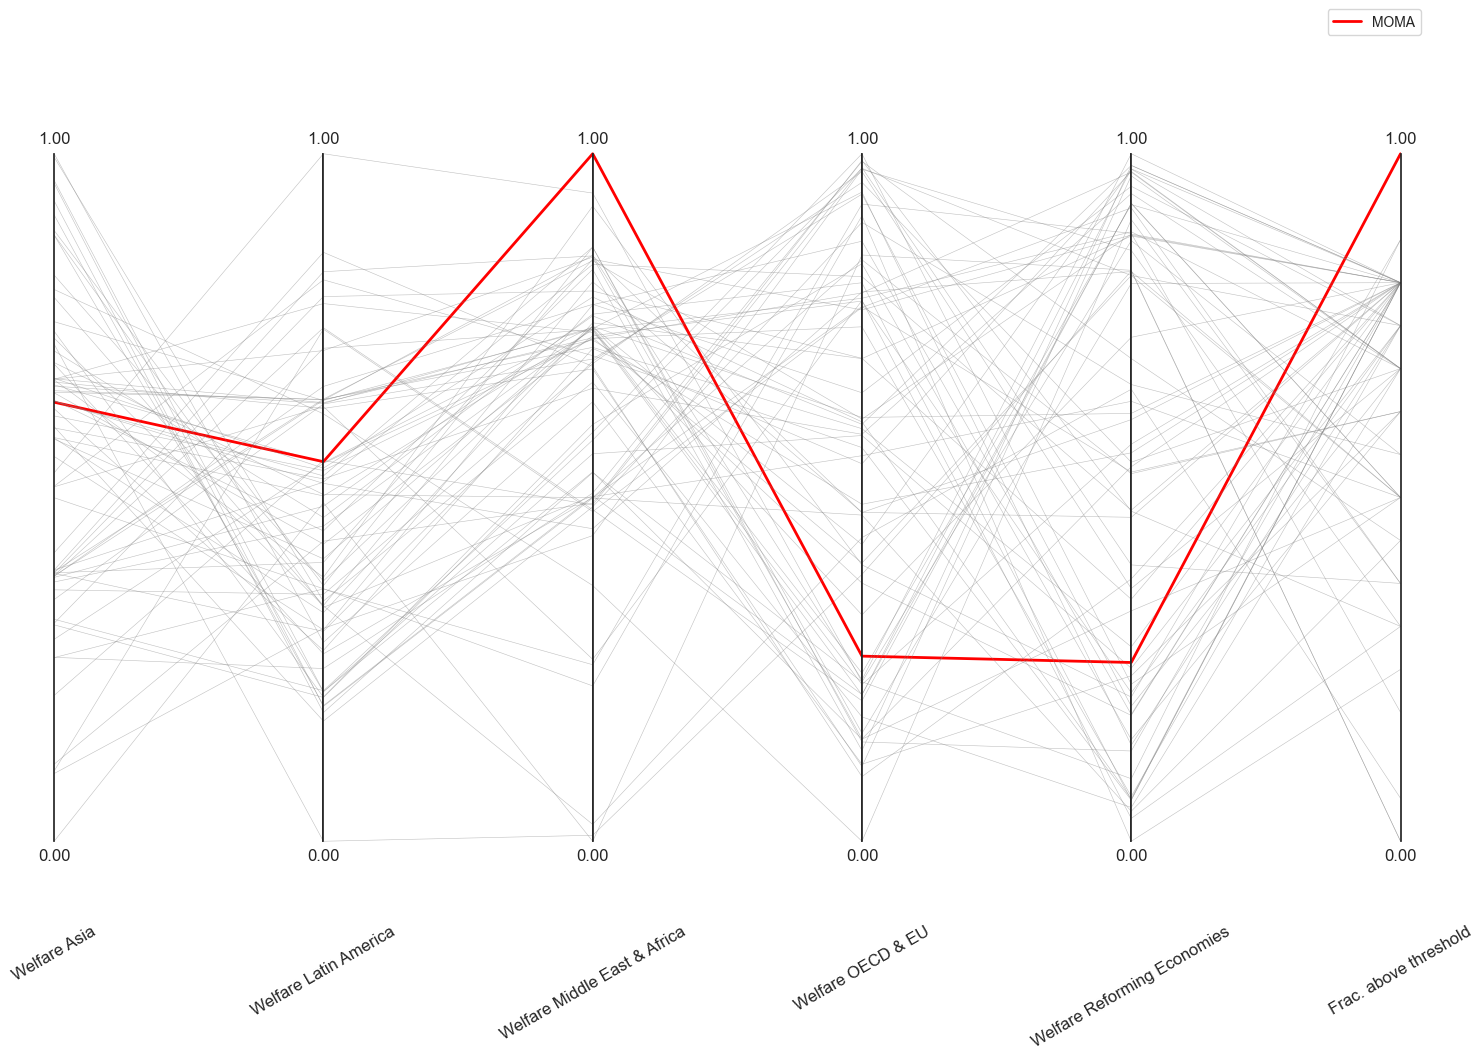

,macro_welfare_R5ASIA,macro_welfare_R5LAM,macro_welfare_R5MAF,macro_welfare_R5OECD,macro_welfare_R5REF,fraction_above_threshold,type
0,1.000000,0.289385,0.639247,0.112002,0.240711,0.6250,MOMA_reference_set.csv
1,0.212102,0.553792,0.489135,0.979688,0.401957,0.3750,MOMA_reference_set.csv
2,0.267546,0.251256,0.506389,0.988949,0.702087,0.4375,MOMA_reference_set.csv
3,0.618640,0.539256,0.730895,0.748282,0.065242,0.7500,MOMA_reference_set.csv
4,0.535879,1.000000,0.942817,0.231889,0.090952,0.8750,MOMA_reference_set.csv
...,...,...,...,...,...,...,...
66,0.696273,0.504325,0.499732,0.777810,0.536970,0.6250,MOMA_reference_set.csv
67,0.640407,0.520563,0.454581,0.799001,0.828660,0.5000,MOMA_reference_set.csv
68,0.713282,0.470854,0.766647,0.812366,0.060002,0.8125,MOMA_reference_set.csv
69,0.390091,0.792293,0.800365,0.702449,0.351957,0.8125,MOMA_reference_set.csv


In [6]:
from justice.util.visualizer import visualize_tradeoffs

"""
R5ASIA  # Asia (R5)
R5LAM   # Latin America (R5)
R5MAF   # Middle East & Africa (R5)
R5OECD  # OECD & EU (R5)
R5REF   # Reforming Economies (R5)
"""

visualize_tradeoffs(
    input_data=["MOMA_reference_set.csv"],
    figsize=(15, 10),
    set_style="whitegrid",
    font_scale=1.8,
    colourmap="bright",
    linewidth=0.4,
    alpha=0.5,
    path_to_data="data/temporary/MOMA_DATA/200k/",
    path_to_output="data/temporary/MOMA_DATA/200k",
    scaling=True,
    feature_range=(0, 1),
    column_labels=None,
    legend_labels=None,
    show_legend=True,
    axis_rotation=30,
    fontsize=12,
    list_of_objectives=[
        "macro_welfare_R5ASIA",
        "macro_welfare_R5LAM",
        "macro_welfare_R5MAF",
        "macro_welfare_R5OECD",
        "macro_welfare_R5REF",
        "fraction_above_threshold",
    ],
    direction_of_optimization=[
        "max",
        "max",
        "max",
        "max",
        "max",
        "min",
    ],
    pretty_labels=[

        "Welfare Asia",
        "Welfare Latin America",
        "Welfare Middle East & Africa",
        "Welfare OECD & EU",
        "Welfare Reforming Economies",
        "Frac. above threshold",
    ],
    default_colors=["red", "blue"],
    top_percentage=0.1,
    show_best_solutions=True,
    highlight_indices={"MOMA_reference_set.csv": [23]},  # ← new: list of row‐indices you want to highlight
    highlight_factor=5,  # ← new: how many× thicker for highlighted rows
    # temperature_filter=False,
    saving=False,
)








#### Computing Hypervolume

In [10]:
## This block computes the Hypervolume for the reference set

filenames = [


    # Loading Archives for the different seeds  Borg
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_0.tar.gz", 
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_1.tar.gz",
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_2.tar.gz",
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_3.tar.gz",
]

reference_set = "MOMA_reference_set.csv"
# reference_set =  "final_archive/100000.csv"

with multiprocessing.Pool() as pool:
    # Enumerate through the filenames
    for filename in filenames:
        scores = calculate_hypervolume_from_archives(
            list_of_objectives=list_of_objectives,
            direction_of_optimization=direction_of_optimization,
            input_data_path=data_path,
            file_name=filename,
            output_data_path=path + "/hypervolumes/",
            saving=True,
            global_reference_set=True,
            global_reference_set_path=path,
            global_reference_set_file=reference_set,
            pool=pool,
          )  # NOTE: Change this according to the PF refset
        



Loading archives for MOMA_200000_ref2_11_0.tar.gz
Archives loaded
list_of_archives:  (2560, 6)
reference_set (71, 6)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000, 60000, 70000, 80000, 90000]
Computing hypervolume for  MOMA_200000_ref2_11_0.tar.gz
Time taken for Hypervolume Calculation: 3.124 seconds
data/temporary/MOMA_DATA/200k//hypervolumes//MOMA_200000_ref2_11_0_hv.csv
Loading archives for MOMA_200000_ref2_11_1.tar.gz
Archives loaded
list_of_archives:  (2536, 6)
reference_set (71, 6)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000, 60000, 70000, 80000, 90000]
Computing hypervolume for  MOMA_200000_ref2_11_1.tar.gz
Time taken for Hypervolume Calculation: 0.032 seconds
data/temporary/MOMA_DATA/200k//hypervolumes//MOMA_

In [11]:
input_data_path_list = {
    
   "MOMA": [
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_0_hv.csv", 
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_1_hv.csv",
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_2_hv.csv",
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_3_hv.csv",
    ],
}


fig = plot_hypervolume(
    path_to_data=path,
    path_to_output=path,
    input_data=input_data_path_list,
    yaxis_upper_limit=1.0,
    width=1000,
    height=800,
    fontsize=20,
    saving=True,
)

fig.show()

In [11]:

# NOTE: Restart the Kernel after each run. Jupyter has some issues running this which corrupts the data file

import IPython
import pandas as pd
from justice.util.output_data_processor import reevaluate_optimal_policy, reevaluated_optimal_policy_variable_extractor
from justice.util.model_time import TimeHorizon
from justice.util.data_loader import DataLoader


# ############################################################################################################
scenario_list = ["SSP245"]
start_year = 2015
end_year = 2300
data_timestep = 5
timestep = 1

data_loader = DataLoader()
region_list = data_loader.REGION_LIST

# Set the time horizon
time_horizon = TimeHorizon(
    start_year=start_year,
    end_year=end_year,
    data_timestep=data_timestep,
    timestep=timestep,
)

list_of_years = time_horizon.model_time_horizon

# NOTE: The following code generates large dataframes and saved them in the data/temporary folder. Size is ~ 1.5 GB each run
reevaluate_optimal_policy(
    
    # Change this
    input_data=[
        "MOMA_reference_set.csv",

    ],
    path_to_rbf_weights="data/temporary/MOMA_DATA/",  #  reevaluation
    path_to_output="data/temporary/MOMA_DATA/",
    direction_of_optimization=[
        "max",
        "max",
        "max",
        "max",
        "max"
        "min",

    ],
    rbf_policy_index= 100, # This chooses policy for a particular rival framing. NOTE: Can also set to the index directly
    list_of_objectives=[
    "macro_welfare_R5ASIA",
    "macro_welfare_R5LAM",
    "macro_welfare_R5MAF",
    "macro_welfare_R5OECD",
    "macro_welfare_R5REF",
    "fraction_above_threshold",
    ],
    scenario_list=scenario_list,  
)


# Restarting the Kernel
IPython.Application.instance().kernel.do_shutdown(True) #automatically restarts kernel



index for policy:  100
2 SSP245


KeyboardInterrupt: 

## Testing

In [ ]:
import json
import numpy as np
from pathlib import Path

from ema_workbench import Constant
from justice.util.EMA_model_wrapper import model_wrapper_momadps, _compute_inverse_range

from justice.util.regional_configuration import aggregate_by_macro_region, build_macro_region_mapping
from justice.util.data_loader import DataLoader
from justice.util.enumerations import *
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

def smoke_test_momadps(config_path, mapping_base_path="data/input", seed=42):
    rng = np.random.default_rng(seed)

    with open(config_path, "r", encoding="utf-8") as file:
        config = json.load(file)

    start_year = config["start_year"]
    end_year = config["end_year"]
    data_timestep = config["data_timestep"]
    timestep = config["timestep"]
    emission_control_start_year = config["emission_control_start_year"]
    n_rbfs = config["n_rbfs"]
    n_inputs = config["n_inputs"]
    temperature_year_of_interest = config["temperature_year_of_interest"]
    stochastic_run = config["stochastic_run"]
    climate_members = config.get("climate_ensemble_members")

    min_temperature = config["min_temperature"]
    max_temperature = config["max_temperature"]
    min_temperature_change = config["min_temperature_change"]
    max_temperature_change = config["max_temperature_change"]
    consumption_min = config["consumption_min"]
    consumption_max = config["consumption_max"]

    data_loader = DataLoader()
    region_list = data_loader.REGION_LIST
    n_regions = len(region_list)

    time_horizon = TimeHorizon(
        start_year=start_year,
        end_year=end_year,
        data_timestep=data_timestep,
        timestep=timestep,
    )
    emission_start_ts = time_horizon.year_to_timestep(
        year=emission_control_start_year, timestep=timestep
    )
    temperature_year_index = time_horizon.year_to_timestep(
        year=temperature_year_of_interest, timestep=timestep
    )
    n_timesteps = len(time_horizon.model_time_horizon)

    r5_json = Path(mapping_base_path) / "R5_regions.json"
    rice50_json = Path(mapping_base_path) / "rice50_regions_dict.json"
    region_to_macro, macro_region_names = build_macro_region_mapping(
        region_list=region_list,
        r5_json_path=r5_json,
        rice50_json_path=rice50_json,
    )
    n_macro_regions = len(macro_region_names)

    # Derive RBF shapes
    rbf_template = RBF(
        n_rbfs=(n_inputs + 2),
        n_inputs=n_inputs,
        n_outputs=1,
    )
    centers_shape, radii_shape, weights_shape = rbf_template.get_shape()
    centers_len, radii_len, weights_len = (
        centers_shape[0],
        radii_shape[0],
        weights_shape[0],
    )

    # Build kwargs dictionary with random RBF parameters
    kwargs = {
        "ssp_rcp_scenario": rng.integers(0, 8),
        "social_welfare_function_type": WelfareFunction.from_index(0).value[0],
        "economy_type": Economy.NEOCLASSICAL.value,
        "damage_function_type": DamageFunction.KALKUHL.value,
        "abatement_type": Abatement.ENERDATA.value,
        "stochastic_run": stochastic_run,
        "n_regions": n_regions,
        "n_timesteps": n_timesteps,
        "emission_control_start_timestep": emission_start_ts,
        "n_inputs_rbf": n_inputs,
        "n_outputs_rbf": 1,
        "temperature_year_of_interest_index": temperature_year_index,
        "climate_ensemble_members": climate_members,
        "min_temperature": min_temperature,
        "max_temperature": max_temperature,
        "min_temperature_change": min_temperature_change,
        "max_temperature_change": max_temperature_change,
        "consumption_min": consumption_min,
        "consumption_max": consumption_max,
        "region_to_macro": region_to_macro.tolist(),
        "macro_region_names": list(macro_region_names),
        "n_macro_regions": n_macro_regions,
    }

    for macro_idx in range(n_macro_regions):
        kwargs.update(
            {
                f"center {macro_idx} {i}": rng.uniform(-1.0, 1.0)
                for i in range(centers_len)
            }
        )
        kwargs.update(
            {
                f"radii {macro_idx} {i}": rng.uniform(1e-4, 1.0)
                for i in range(radii_len)
            }
        )
        kwargs.update(
            {
                f"weights {macro_idx} {i}": rng.uniform(1e-4, 1.0)
                for i in range(weights_len)
            }
        )

    # Run the wrapper once with random levers
    results = model_wrapper_momadps(**kwargs)
    print("Wrapper objectives:", results)


if __name__ == "__main__":
    smoke_test_momadps("analysis/momadps_config.json")

In [10]:
df.columns

Index(['center 0 0', 'center 0 1', 'center 0 2', 'center 0 3', 'center 0 4',
       'center 0 5', 'center 0 6', 'center 0 7', 'center 0 8', 'center 0 9',
       ...
       'weights 4 1', 'weights 4 2', 'weights 4 3', 'weights 4 4',
       'macro_welfare_R5ASIA', 'macro_welfare_R5LAM', 'macro_welfare_R5MAF',
       'macro_welfare_R5OECD', 'macro_welfare_R5REF',
       'fraction_above_threshold'],
      dtype='object', length=181)

# Simulating with Optimal policies

In [15]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Dict, Any, Optional

from justice.util.enumerations import Economy, DamageFunction, Abatement, WelfareFunction, Scenario
from justice.model import JUSTICE
from justice.util.emission_control_constraint import EmissionControlConstraint
from solvers.emodps.rbf import RBF
from justice.util.regional_configuration import aggregate_by_macro_region
from justice.objectives.objective_functions import fraction_of_ensemble_above_threshold

from justice.util.regional_configuration import build_macro_region_mapping



from justice.util.data_loader import DataLoader

from justice.util.model_time import TimeHorizon


def run_momadps_policy(
    policy_csv_path: str,
    policy_index: int,
    scenario: int = 2,
    config_path: str = "momadps_config.json",
    mapping_base_path: str = "data/input",
) -> Tuple[Tuple[float, ...], Dict[str, np.ndarray]]:
    """
    Re-simulate JUSTICE under a multi-agent RBF policy taken from a CSV row.

    Parameters
    ----------
    policy_csv_path : str
        Path to the CSV file containing optimization results (centers/radii/weights/metrics).
    policy_index : int
        Row index to extract. Supports negative indices (like pandas .iloc).
    scenario : Scenario
        Which SSP-RCP scenario to run (default: SSP2-RCP45).
    config_path : str
        JSON config used during MOMADPS optimization (e.g., "momadps_config.json").
    mapping_base_path : str
        Directory containing "R5_regions.json" and "rice50_regions_dict.json".

    Returns
    -------
    objectives : Tuple[float, ...]
        A 6-tuple (five macro welfare metrics + fraction-above-threshold) matching the wrapper outputs.
    datasets : Dict[str, np.ndarray]
        Full JUSTICE datasets dictionary; includes a "constrained_emission_control_rate" array.
    """

    # --- Load config & policy row --------------------------------------------------
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    df = pd.read_csv(policy_csv_path)
    if policy_index < -len(df) or policy_index >= len(df):
        raise IndexError(
            f"policy_index {policy_index} out of bounds for CSV with {len(df)} rows."
        )
    policy_row = df.iloc[int(policy_index)]

    # --- Extract shared settings (mirrors analyzer setup) --------------------------
    start_year = config["start_year"]
    end_year = config["end_year"]
    data_timestep = config["data_timestep"]
    timestep = config["timestep"]
    emission_control_start_year = config["emission_control_start_year"]
    n_rbfs = config["n_rbfs"]
    n_inputs = config["n_inputs"]
    temperature_year_of_interest = config["temperature_year_of_interest"]
    stochastic_run = config["stochastic_run"]
    climate_members = config.get("climate_ensemble_members")

    min_temperature = config["min_temperature"]
    max_temperature = config["max_temperature"]
    min_temperature_change = config["min_temperature_change"]
    max_temperature_change = config["max_temperature_change"]
    consumption_min = config["consumption_min"]
    consumption_max = config["consumption_max"]

    data_loader = DataLoader()
    region_list = data_loader.REGION_LIST
    n_regions = len(region_list)

    time_horizon = TimeHorizon(
        start_year=start_year,
        end_year=end_year,
        data_timestep=data_timestep,
        timestep=timestep,
    )
    emission_start_ts = time_horizon.year_to_timestep(
        year=emission_control_start_year, timestep=timestep
    )
    temperature_year_index = time_horizon.year_to_timestep(
        year=temperature_year_of_interest, timestep=timestep
    )
    n_timesteps = len(time_horizon.model_time_horizon)

    r5_json = Path(mapping_base_path) / "R5_regions.json"
    rice50_json = Path(mapping_base_path) / "rice50_regions_dict.json"
    region_to_macro, macro_region_names = build_macro_region_mapping(
        region_list=region_list,
        r5_json_path=r5_json,
        rice50_json_path=rice50_json,
    )
    n_macro_regions = len(macro_region_names)

    macro_region_counts = np.bincount(region_to_macro, minlength=n_macro_regions).astype(float)
    macro_region_counts = macro_region_counts[:, None]  # (n_macro, 1)

    # --- Construct RBFs exactly as in optimization ---------------------------------
    rbf_template = RBF(
        n_rbfs=(n_inputs + 2),
        n_inputs=n_inputs,
        n_outputs=1,
    )
    centers_shape, radii_shape, weights_shape = rbf_template.get_shape()
    centers_len, radii_len, weights_len = (
        centers_shape[0],
        radii_shape[0],
        weights_shape[0],
    )

    macro_rbfs = []
    for macro_idx in range(n_macro_regions):
        centers = np.array(
            [policy_row[f"center {macro_idx} {i}"] for i in range(centers_len)]
        )
        radii = np.array(
            [policy_row[f"radii {macro_idx} {i}"] for i in range(radii_len)]
        )
        weights = np.array(
            [policy_row[f"weights {macro_idx} {i}"] for i in range(weights_len)]
        )

        rbf = RBF(
            n_rbfs=(n_inputs + 2),
            n_inputs=n_inputs,
            n_outputs=1,
        )
        decision_vars = np.concatenate((centers, radii, weights))
        rbf.set_decision_vars(decision_vars)
        macro_rbfs.append(rbf)

    # --- Instantiate JUSTICE -------------------------------------------------------
    model = JUSTICE(
        scenario=scenario,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function=WelfareFunction.UTILITARIAN,
        stochastic_run=stochastic_run,
        climate_ensembles=climate_members,
    )

    no_of_ensembles = model.__getattribute__("no_of_ensembles")

    emission_constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=emission_start_ts,
        min_emission_control_rate=0.01,
    )

    inv_temperature_range = 1.0 / (max_temperature - min_temperature)
    inv_temperature_change_range = 1.0 / (max_temperature_change - min_temperature_change)
    inv_consumption_range = 1.0 / (consumption_max - consumption_min)

    regional_emission_control_rate = np.zeros(
        (n_regions, n_timesteps, no_of_ensembles), dtype=float
    )
    constrained_emission_control_rate = np.zeros_like(regional_emission_control_rate)
    macro_emission_control_rate = np.zeros(
        (n_macro_regions, n_timesteps, no_of_ensembles), dtype=float
    )
    macro_consumption_history = np.zeros(
        (n_macro_regions, n_timesteps, no_of_ensembles), dtype=float
    )

    rbf_input_buffer = np.empty((n_inputs, no_of_ensembles), dtype=float)
    previous_temperature = np.zeros(no_of_ensembles, dtype=float)
    previous_temperature_change = np.zeros(no_of_ensembles, dtype=float)

    # --- Simulation loop -----------------------------------------------------------
    for timestep in range(n_timesteps):
        constrained_emission_control_rate[:, timestep, :] = (
            emission_constraint.constrain_emission_control_rate(
                regional_emission_control_rate[:, timestep, :],
                timestep,
                allow_fallback=False,
            )
        )

        model.stepwise_run(
            emission_control_rate=constrained_emission_control_rate[:, timestep, :],
            timestep=timestep,
            endogenous_savings_rate=True,
        )
        datasets = model.stepwise_evaluate(timestep=timestep)

        global_temperature = datasets["global_temperature"][timestep, :]
        consumption_per_capita = datasets["consumption_per_capita"][:, timestep, :]

        if timestep == 0:
            temperature_change = np.zeros_like(global_temperature)
            previous_temperature = global_temperature.copy()
            previous_temperature_change = temperature_change.copy()
        elif timestep % 5 == 0:
            temperature_change = global_temperature - previous_temperature
            previous_temperature = global_temperature.copy()
            previous_temperature_change = temperature_change.copy()
        else:
            temperature_change = previous_temperature_change

        rbf_input_buffer[0, :] = np.clip(
            (global_temperature - min_temperature) * inv_temperature_range,
            0.0,
            1.0,
        )
        rbf_input_buffer[1, :] = np.clip(
            (temperature_change - min_temperature_change)
            * inv_temperature_change_range,
            0.0,
            1.0,
        )

        aggregated_consumption = aggregate_by_macro_region(
            consumption_per_capita, region_to_macro
        )
        macro_mean_consumption = aggregated_consumption / macro_region_counts
        macro_consumption_history[:, timestep, :] = macro_mean_consumption

        normalized_macro_consumption = np.clip(
            (macro_mean_consumption - consumption_min) * inv_consumption_range,
            0.0,
            1.0,
        )

        if timestep < n_timesteps - 1:
            for macro_idx, rbf in enumerate(macro_rbfs):
                rbf_input_buffer[2, :] = normalized_macro_consumption[macro_idx, :]
                macro_output = rbf.apply_rbfs(rbf_input_buffer)
                macro_emission_control_rate[macro_idx, timestep + 1, :] = macro_output

            regional_emission_control_rate[:, timestep + 1, :] = macro_emission_control_rate[
                region_to_macro, timestep + 1, :
            ]

    datasets = model.evaluate()
    datasets["constrained_emission_control_rate"] = constrained_emission_control_rate
    datasets["macro_consumption_history"] = macro_consumption_history
    datasets["regional_emission_control_rate"] = regional_emission_control_rate

    spatially_disaggregated_welfare = (
        model.welfare_function.calculate_spatially_disaggregated_welfare(
            macro_consumption_history
        )
    )

    fraction_above_threshold = fraction_of_ensemble_above_threshold(
        temperature=datasets["global_temperature"],
        temperature_year_index=temperature_year_index,
        threshold=2.0,
    )

    objectives = (
        float(spatially_disaggregated_welfare[0]),
        float(spatially_disaggregated_welfare[1]),
        float(spatially_disaggregated_welfare[2]),
        float(spatially_disaggregated_welfare[3]),
        float(spatially_disaggregated_welfare[4]),
        float(fraction_above_threshold),
    )

    model.hard_reset()
    return objectives, datasets




# Usage
objectives, datasets = run_momadps_policy(
    policy_csv_path="data/temporary/MOMA_DATA/200k/MOMA_reference_set.csv",
    policy_index=23,  # or any row index
    scenario=2,
    config_path="analysis/momadps_config.json",
    mapping_base_path="data/input",
)

print("Objectives:", objectives)
control = datasets["constrained_emission_control_rate"]
print("Control shape:", control.shape)

# Save constrained emission control rates to npy file
np.save("data/temporary/MOMA_DATA/200k/constrained_emission_control_rate.npy", control)

Objectives: (2097.463416118402, 2852.168874405558, 2680.811652108351, 3351.997652978516, 2102.11335019308, 0.56)
Control shape: (57, 286, 50)


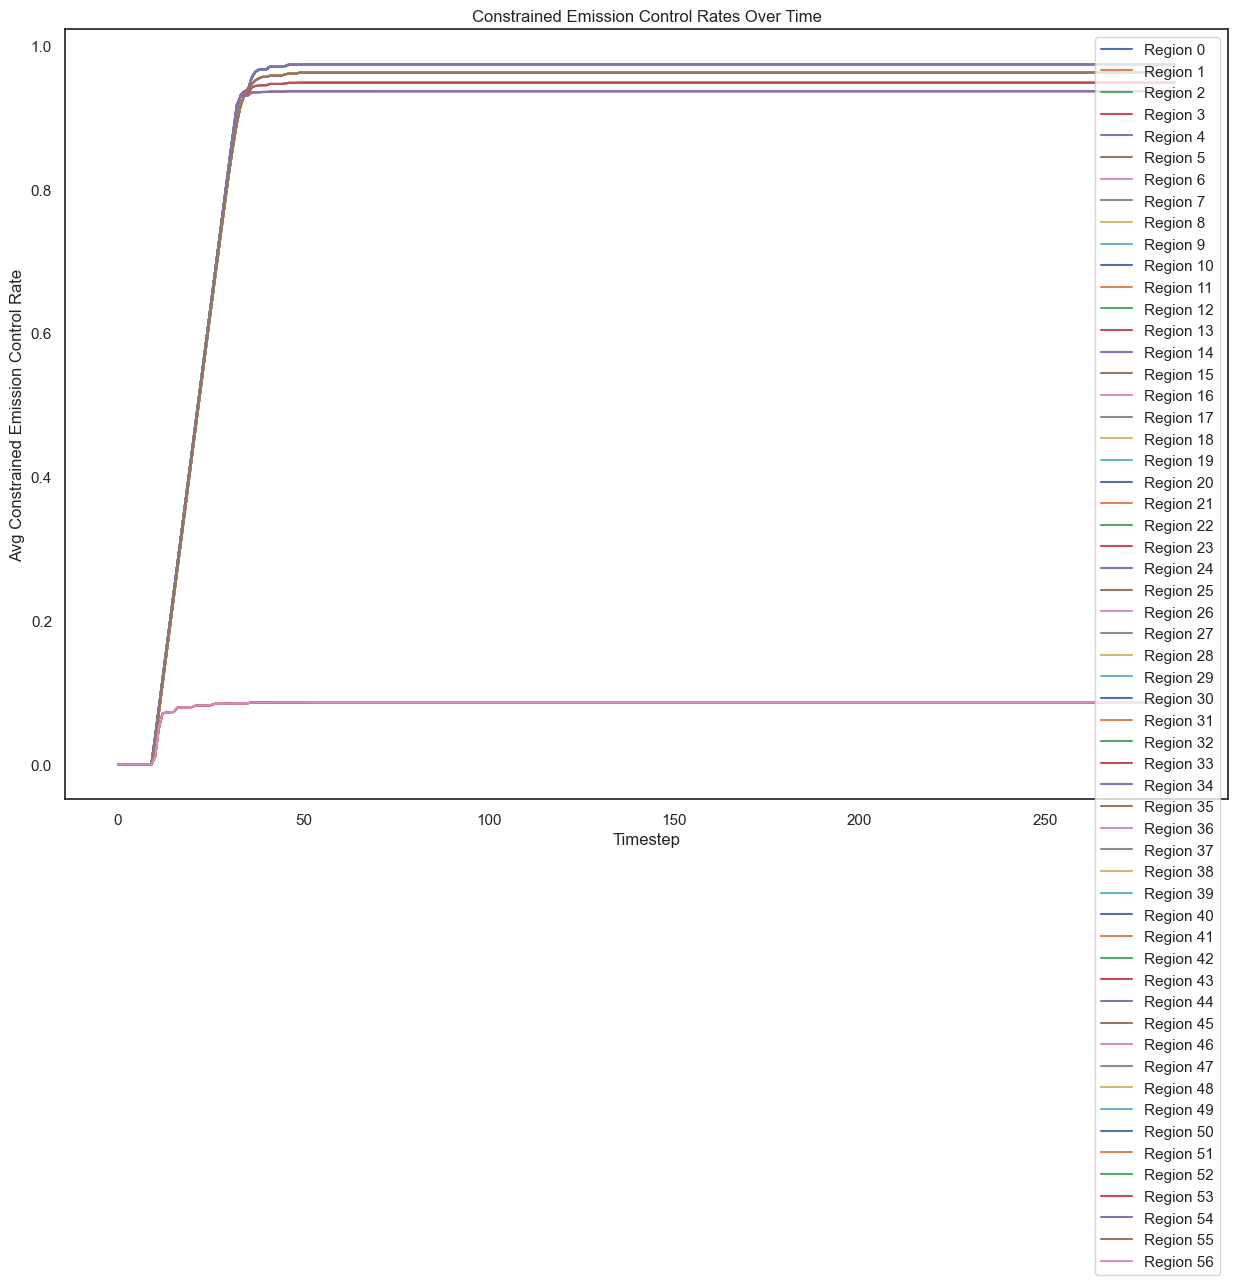

In [17]:
# Plot the constrained emission control rates for the each region over time and taking average over ensembles
import matplotlib.pyplot as plt
avg_control = np.mean(control, axis=2)  # Average over ensembles
n_regions, n_timesteps = avg_control.shape
plt.figure(figsize=(15, 10))
for region_idx in range(n_regions):
    plt.plot(avg_control[region_idx, :], label=f"Region {region_idx}")
plt.xlabel("Timestep")
plt.ylabel("Avg Constrained Emission Control Rate")
plt.title("Constrained Emission Control Rates Over Time")
plt.legend()
plt.show()



In [16]:
import numpy as np
import plotly.express as px

import pandas as pd

from justice.util.visualizer import plot_choropleth_2D_data

path = "data/temporary/MOMA_DATA/200k/"
fig, prior_data = plot_choropleth_2D_data(
    path_to_data=path,
    path_to_output=path, #/rbf_dist_test
    projection= "natural earth1", 
    colourmap= px.colors.sequential.Reds,
    year_to_visualize=2050,
    input_data_path_list=[



        "constrained_emission_control_rate.npy",
       


    ],
        
    data_label="Emission Control Rate",
    legend_label="", 
    data_normalization=True,
    saving=True,
    show_colorbar=True,
    normalized_colorbar=True,

)

fig.show()


Taking average over the last dimension.
0
